<a href="https://colab.research.google.com/github/NeuralClassification/CNN/blob/develop/RedNeuronalConvolutiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dimensiones de la imagen: (585, 683, 3)
Máximo valor: 1.0
Mínimo valor: 0.0


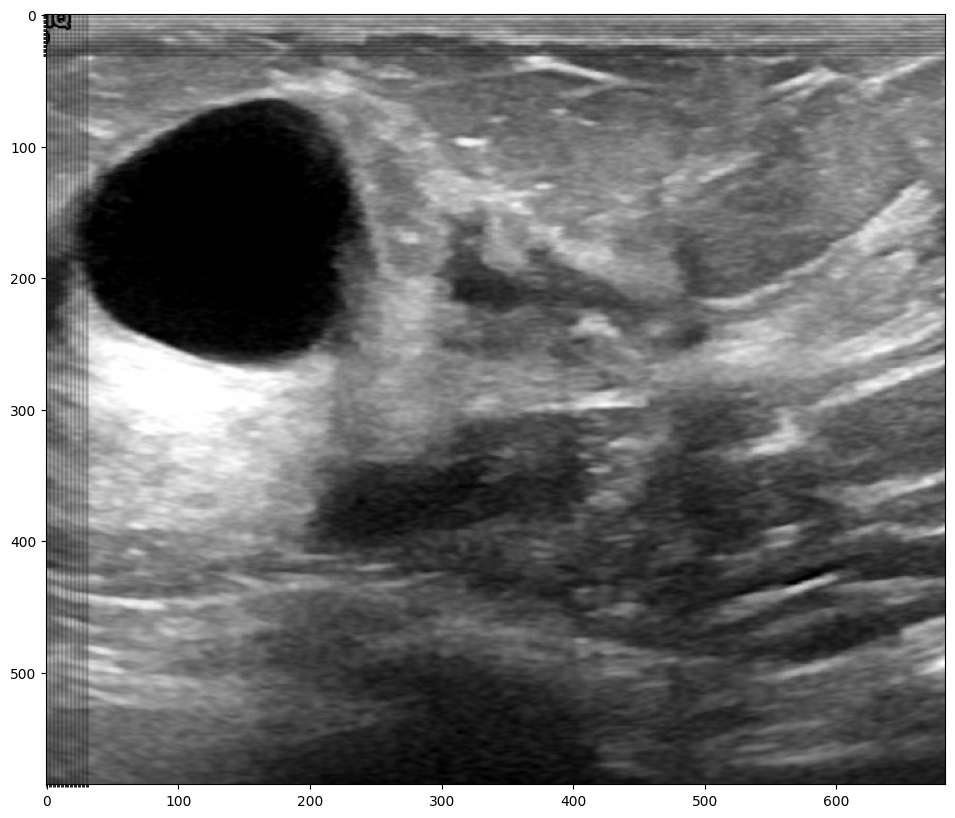

In [4]:
# Prueba Google Colab

import matplotlib.pyplot as plt
import numpy as np
from skimage import io

%matplotlib inline

plt.rcParams['image.cmap'] = 'gray'
image=io.imread("imgs/benign (10).png")/255.0 # imread lee las imagenes con los pixeles codificados como enteros
# en el rango 0-255. Por eso la convertimos a flotante y en el rango 0-1

print("Dimensiones de la imagen:", image.shape)
print("Máximo valor:", image.max())
print("Mínimo valor:", image.min())

plt.figure(figsize=(20,10))
plt.imshow(image)

ax = plt.gca();
ax.set_xticks(np.arange(-.5, 32, 1), minor=True);
ax.set_yticks(np.arange(-.5, 32, 1), minor=True);
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.2)

Dimensiones de la imagen: (585, 683, 3)
Máximo valor: 2.592156862745098
Mínimo valor: -2.388235294117647


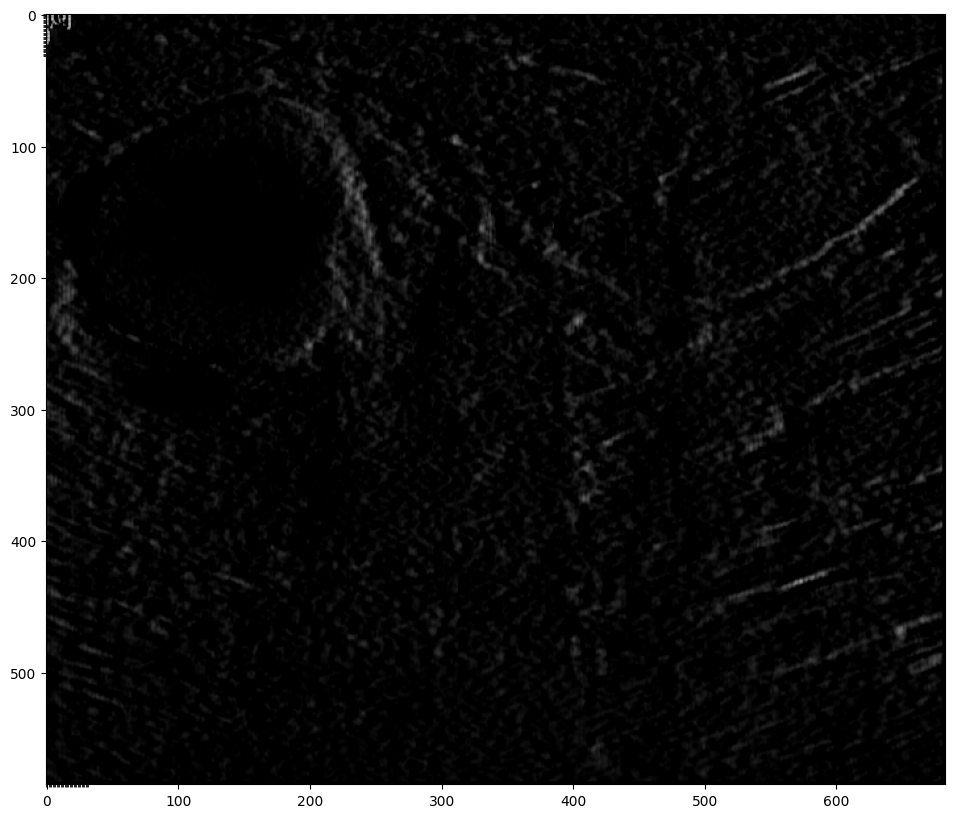

In [10]:
import numpy as np

# Valores del kernel
values = np.array([[-1., 0., 1.],[-1., 0., 1.],[-1., 0., 1.]]) # Detector de bordes verticales
#weights = np.array([[-1., -1., -1.],[0., 0., 0.],[1., 1., 1.]]) # Detector de bordes horizontales
#weights = np.array([[-2., -1., 0.],[-1., 0., 1.],[0., 1., 2.]]) # Detector de bordes diagonales


# Convolución
def convolution(image, kernel):
    # Create a result array with the same shape as the input image to handle color channels
    result = np.zeros_like(image, dtype=float)

    # Recorrido de la imagen
    for j in range(0, image.shape[0]-2):
        for i in range(0, image.shape[1]-2):
            # Apply convolution to each color channel
            for c in range(image.shape[2]):
                aux = 0
                # Recorrido del kernel
                for m in range(0, values.shape[0]):
                    for n in range(0, values.shape[1]):
                        aux += image[j+m][i+n][c] * values[m][n]
                result[j][i][c] = aux
    return result

image_result = convolution(image, values)

print("Dimensiones de la imagen:", image_result.shape)
print("Máximo valor:", image_result.max())
print("Mínimo valor:", image_result.min())

plt.figure(figsize=(20,10))
plt.imshow(image_result, vmin=-1,vmax=1)

ax = plt.gca();
ax.set_xticks(np.arange(-.5, 32, 1), minor=True);
ax.set_yticks(np.arange(-.5, 32, 1), minor=True);
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.2)

plt.imshow(image_result)